# EDA

In [168]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder

In [157]:
# Data Load

df = pd.read_csv("../dataset/train.csv")

df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [118]:
# Stats

print(df.describe())

               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.489021    666.717663   1611.489240    604.696458   1136.705535   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      19.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      38.000000     47.000000     76.000000     27.000000     59.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8505.000000  
mean     304.854791  
std     1145.717189  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       46.000000  
max    24133.000000  


In [119]:
# Null Values

print(df.isnull().sum())

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
Group             0
pass_no           0
dtype: int64


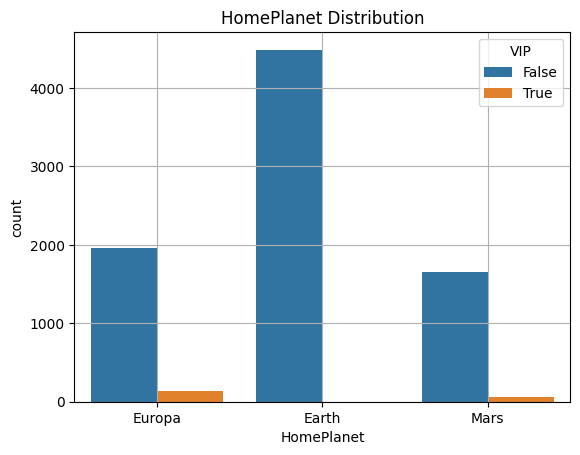

In [120]:
# HomePlanet Distribution

sns.countplot(
    x = "HomePlanet" ,
    hue = "VIP" ,
    data = df
)

plt.title("HomePlanet Distribution")
plt.grid()
plt.show()

# We can clearly see that all the VIP's are from either Europa or Mars .
# Earth planet contributes highest passengers

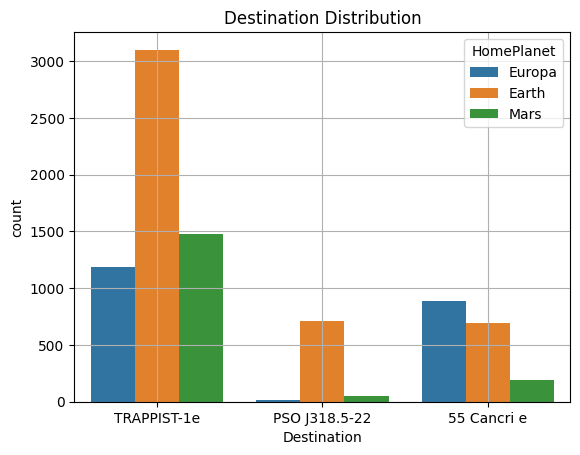

In [121]:
# Destination Distribution

sns.countplot(
    x = "Destination" ,
    hue = "HomePlanet" ,
    data = df
)

plt.title("Destination Distribution")
plt.grid()
plt.show()

In [158]:
# Filling Null Values

df[["Group" , "pass_no"]] = df["PassengerId"].str.split("_" , expand = True)

df["Expense"] = df["RoomService"] + df["FoodCourt"] + df["ShoppingMall"] + df["Spa"] + df["VRDeck"]

expense_column = ["RoomService"	,
                  "FoodCourt" ,
                  "ShoppingMall" ,
                  "Spa" ,
                  "VRDeck"
]

for i in expense_column :
    df.loc[(df["CryoSleep"] == True) & (df[i].isnull()) , i] = 0.0

df.loc[(((df["HomePlanet"] == "Europa") | (df["HomePlanet"] == "Mars")) & (df["VIP"].isnull())) , "VIP"] = True
df.loc[((df["HomePlanet"] == "Earth") & (df["VIP"].isnull())) , "VIP"] = False

df.loc[((df["VIP"] == False) & (df["HomePlanet"].isnull())) , "HomePlanet"] = "Earth"

df.loc[((df["Expense"] == 0.0) & (df["CryoSleep"].isnull())) , "CryoSleep"] = True
df.loc[((df["Expense"] != 0.0) & (df["CryoSleep"].isnull())) , "CryoSleep"] = False

for i in expense_column :
    df.loc[((df["VIP"] == True) & (df[i].isnull())) , i] = float((df[df["VIP"] == True])[i].median())

for i in expense_column :
    df.loc[((df["VIP"] == False) & (df[i].isnull())) , i] = float((df[df["VIP"] == False])[i].median())

unique_group = df["Group"].unique().tolist()

for i in unique_group:
    cabin = df.loc[
        (df["Group"] == i) & (df["Cabin"].notnull()),
        "Cabin"
    ]

    if not cabin.empty:
        df.loc[
            (df["Group"] == i) & (df["Cabin"].isnull()),
            "Cabin"
        ] = cabin.iloc[0]

df[["Deck", "CabinNum", "Side"]] = df["Cabin"].str.split("/", expand=True)

df = df.dropna(subset = ["Cabin"])
df = df.dropna(subset = ["HomePlanet"])

df["Age"] = df["Age"].fillna(df["Age"].median())

In [159]:
df[["Deck", "CabinNum", "Side"]] = df["Cabin"].str.split("/", expand=True)

df = df.drop(["Name" , "PassengerId" , "Cabin" , "pass_no" , "Destination" , "Expense"] , axis = 1)

In [160]:
print(df.isnull().sum())

HomePlanet      0
CryoSleep       0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Group           0
Deck            0
CabinNum        0
Side            0
dtype: int64


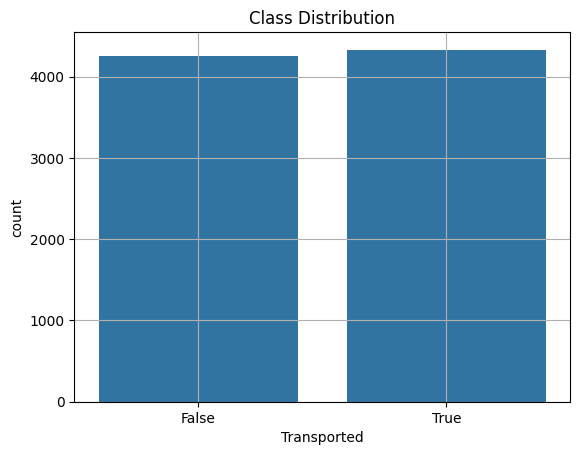

In [162]:
# Imbalance Check

sns.countplot(
    x = "Transported" ,
    data = df
)

plt.title("Class Distribution")
plt.grid()
plt.show()

# This dataset is accurately balanced

In [167]:
# Catagorial and Numerical Columns

print("Numerical :")
print(df.select_dtypes(include = ["number"]).columns)

print()

print("Catagorial :")
print(df.select_dtypes(include = ["object" , "string"]).columns)

Numerical :
Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'], dtype='str')

Catagorial :
Index(['HomePlanet', 'CryoSleep', 'VIP', 'Group', 'Deck', 'CabinNum', 'Side'], dtype='str')


In [170]:
# Base Model (Feature Importance)

X_train = df.drop(["Transported"] , axis = 1)
y_train = df["Transported"]

